# Step 1: Install Dependencies

This notebook uses PyTorch models exclusively.

- 🤗 transformers for model loading (works on CUDA and MPS)
- PEFT for LoRA adapters
- TRL for training

All components are standard PyTorch libraries.


In [1]:
# Install required packages for this notebook.
%pip install -q datasets trl transformers wandb mlx-tune optuna tensorboard huggingface_hub seaborn   # mlx-tune on MacOS
# %pip install -q unsloth   # unsloth for CUDA

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlx-audio 0.2.10 requires mlx-lm<0.30.0,>=0.18.0, but you have mlx-lm 0.31.3 which is incompatible.
mlx-audio 0.2.10 requires transformers<5.0.0,>=4.49.0, but you have transformers 5.5.0 which is incompatible.
mlx-audio-plus 0.1.8 requires mlx-lm<0.30.0,>=0.18.0, but you have mlx-lm 0.31.3 which is incompatible.
mlx-audio-plus 0.1.8 requires transformers<5.0.0,>=4.49.0, but you have transformers 5.5.0 which is incompatible.
unsloth 2026.4.8 requires torch<2.11.0,>=2.4.0, but you have torch 2.11.0 which is incompatible.
unsloth-zoo 2026.4.9 requires torch<2.11.0,>=2.4.0, but you have torch 2.11.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


# Step 1a: Login to wandb

EXECUTE ONCE TO LOGIN TO WANDB ACCOUNT. You can create a free account at https://wandb.ai/site.

In [1]:
import wandb
import os
os.environ["WANDB_API_KEY"] = "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"

# Step 2: Load Model

We load the model using 🤗 transformers, which works identically on both CUDA and MPS.

The model is moved to the detected device after loading.


In [2]:
from pathlib import Path
import os
import torch

if torch.cuda.is_available():
    print(f"CUDA is available. Selecting GPU: {torch.cuda.get_device_name(0)}")
    DEVICE = torch.device("cuda")
    import unsloth    
    print(f"Unsloth version: {unsloth.__version__}")
    # from unsloth import FastLanguageModel
elif torch.backends.mps.is_available():
    print("Apple Silicon GPU is available. Selecting MPS device.")
    DEVICE = torch.device("mps")
    import mlx_tune as mlt
    print(f"MLX Tune version: {mlt.__version__}")
    # from mlx_tune import FastLanguageModel
else:
    print("No GPU available. Using CPU.")
    DEVICE = torch.device("cpu")

# -------------------------
# User-configurable paths
# -------------------------
LOCAL_MODEL_DIR = os.path.expanduser("~/.lmstudio/models/unsloth/Llama-3.2-3B/")
HF_MODEL_ID = "unsloth/Llama-3.2-3B-bnb-4bit"
HF_MODEL_ID_2 = "unsloth/Llama-3.2-3B"

# -------------------------
# Load model + tokenizer
# -------------------------
# max_seq_length = 2048

base_model = None
tokenizer = None
model_source = None

# Load with transformers (works on both CUDA and MPS)
try:
    from transformers import AutoModelForCausalLM, AutoTokenizer
    print("Loading model with transformers...")
    candidate_sources = []
    if Path(LOCAL_MODEL_DIR).exists():
        candidate_sources.append(LOCAL_MODEL_DIR)
    candidate_sources.append(HF_MODEL_ID)
    candidate_sources.append(HF_MODEL_ID_2)
    for src in candidate_sources:
        try:
            print(f"Trying transformers load from: {src}")
            tokenizer = AutoTokenizer.from_pretrained(src, trust_remote_code=True)
            base_model = AutoModelForCausalLM.from_pretrained(
                src,
                dtype=None,  # Let transformers decide the optimal dtype
                low_cpu_mem_usage=True,
                trust_remote_code=True,
            )
            
            model_source = src
            break
        except Exception as e:
            print(f"  -> failed: {e}")
    
    if base_model is None:
        raise RuntimeError("Failed to load model.")
    
    print(f"\n✓ Loaded model source: {model_source}")
    # print(f"✓ Max sequence length: {max_seq_length}")
    
    # Move to device
    base_model.to(DEVICE)
except Exception as e:
    print(f"Transformers failed: {e}")
    raise


Apple Silicon GPU is available. Selecting MPS device.


W0503 01:28:50.510000 84920 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


MLX Tune version: 0.4.7
Loading model with transformers...
Trying transformers load from: unsloth/Llama-3.2-3B-bnb-4bit


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]


✓ Loaded model source: unsloth/Llama-3.2-3B-bnb-4bit


# Step 3: Attach LoRA Adapters

We use PEFT to attach LoRA adapters. This works for any PyTorch model loaded via transformers.

Parameters: rank=8, alpha=8.


In [3]:
# Attach LoRA adapters with PEFT (works on CUDA and MPS)
ft_model = None
if base_model is not None:
    try:        
        from peft import get_peft_model, LoraConfig
        
        peft_config = LoraConfig(
            r=8,
            lora_alpha=8,
            target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
            lora_dropout=0,
            bias="none",
            task_type="CAUSAL_LM",
        )
        
        ft_model = get_peft_model(base_model, peft_config)
        print(f"✓ LoRA adapters attached via PEFT")
    except Exception as e:
        print(f"⚠ Failed to attach LoRA: {e}")
else:
    print("⚠ Model not loaded, skipping LoRA.")

# Check trainable parameters
try:
    trainable_params = sum(p.numel() for p in ft_model.parameters() if getattr(p, "requires_grad", False))
    print(f"✓ Trainable parameters: {trainable_params:,}")
    # print(f"✓ Trainable parameters: {sum(p.numel() for p in ft_model.parameters() if p.requires_grad):,}")
except Exception:
    print("✓ Trainable parameters: unavailable")


✓ LoRA adapters attached via PEFT
✓ Trainable parameters: 12,156,928


# Step 4: Load Dataset (Local First, HF Fallback)

This cell checks a configurable local dataset directory first.

Load order:
1. If a `save_to_disk` dataset is found, load with `load_from_disk`.
2. Else if parquet files are found, load them directly.
3. Else fallback to Hugging Face dataset download.

This keeps your workflow offline-friendly and faster when data is already present.

In [4]:
from pathlib import Path
from datasets import Dataset, load_dataset, load_from_disk

# -------------------------
# User-configurable dataset location
# -------------------------
LOCAL_DATASET_DIR = "./datasets/R1-Distill/v0"
HF_DATASET_ID = "ServiceNow-AI/R1-Distill-SFT"

local_dataset_path = Path(LOCAL_DATASET_DIR)
dataset = None

def _load_dataset_local_first(path: Path):
    # Case 1: Dataset saved via Dataset.save_to_disk(...)
    if (path / "dataset_info.json").exists() or (path / "state.json").exists():
        print(f"Loading dataset from saved Arrow directory: {path}")
        return load_from_disk(str(path))

    # Case 2: Raw parquet files available locally
    parquet_files = sorted(str(p) for p in path.rglob("*.parquet"))
    if parquet_files:
        # For quick validation, load a single parquet file to avoid cross-file schema mismatch.
        # one_file = parquet_files[0]
        print(f"Loading total local parquet files : {len(parquet_files)}")       # Total no of files found
        return load_dataset("parquet", data_files={"train": parquet_files}, split="train")

    return None

if local_dataset_path.exists():
    try:
        dataset = _load_dataset_local_first(local_dataset_path)
    except Exception as e:
        print(f"Local dataset load failed: {e}")
        dataset = None

if dataset is None:
    try:
        print(f"Falling back to HF dataset: {HF_DATASET_ID}")
        dataset = load_dataset(HF_DATASET_ID, 'v0', split="train")
    except Exception as e:
        print(f"HF dataset load failed: {e}")
        print("Using tiny synthetic dataset for quick notebook validation.")
        dataset = Dataset.from_dict(
            {
                "problem": [
                    "If A > B and B > C, who is smallest?",
                    "What is 2 + 2?",
                    "Explain overfitting briefly.",
                ],
                "reannotated_assistant_content": [
                    "C is the smallest.",
                    "2 + 2 = 4.",
                    "Overfitting is when a model memorizes training data and generalizes poorly.",
                ],
            }
        )

# Normalize column names for downstream prompt formatting
if "problem" not in dataset.column_names and "messages" in dataset.column_names:
    def _derive_problem(example):
        user_msgs = [m["content"] for m in example["messages"] if m.get("role") == "user"]
        example["problem"] = user_msgs[0] if user_msgs else ""
        return example

    dataset = dataset.map(_derive_problem)

# Use a very small subset for quick debug runs (set to None for full dataset)
subset_size = 4096
if subset_size is not None and subset_size < len(dataset):
    dataset = dataset.select(range(subset_size))

print(f"\n✓ Dataset loaded: {len(dataset):,} examples")
print(f"✓ Columns: {dataset.column_names}")
print("\nSample problem snippet:")
sample_problem = dataset[0].get("problem", "")
print((sample_problem[:300] + "...") if sample_problem else "<problem not available in this row>")

Loading total local parquet files : 3

✓ Dataset loaded: 4,096 examples
✓ Columns: ['id', 'reannotated_assistant_content', 'problem', 'source', 'solution', 'verified', 'quality_metrics']

Sample problem snippet:
There were 27 boys and 35 girls on the playground at recess. There were _____ children on the playground at recess....


# Step 5: Convert Records to Chat Training Text

SFT expects text in the model's chat format. We transform each example into:
- one user message (`problem`)
- one assistant message (`reannotated_assistant_content`)

Then we apply the tokenizer chat template so training examples match inference-time prompting style.

In [5]:
# Apply chat template (generic handling)

if tokenizer is None:
    raise RuntimeError("Tokenizer not loaded. Run Step 2 first.")

if torch.cuda.is_available():
    from unsloth.chat_templates import get_chat_template
    print("CUDA is available.")
    print(f"Unsloth version: {unsloth.__version__}")
    tokenizer = get_chat_template(
        tokenizer,
        chat_template = "llama-3.1",  # Llama 3.2 uses 3.1 template
    )   
elif torch.backends.mps.is_available():
    print("MPS (Apple Silicon GPU) is available.")
    from mlx_tune.chat_templates import get_chat_template
    print(f"MLX Tune version: {mlt.__version__}")
    tokenizer = get_chat_template(
        tokenizer,
        chat_template = "llama-3.1",  # Llama 3.2 uses 3.1 template
    )
else:
    print("No GPU available. Skipping chat template formatting.")

# Format function for the dataset
def formatting_prompts_func(examples):
    convos = []
    for problem, response in zip(examples["problem"], examples["reannotated_assistant_content"]):
        convo = [
            {"role": "user", "content": problem},
            {"role": "assistant", "content": response},
        ]
        convos.append(convo)
    
    texts = [tokenizer.apply_chat_template(convo, tokenize=False, add_generation_prompt=False)
             for convo in convos]
    return {"text": texts}

# Apply formatting
dataset = dataset.map(formatting_prompts_func, batched=True)

# Pre-tokenize so SFTTrainer gets input_ids + labels directly
# def _tokenize(example):
#     tokens = tokenizer(example["text"], truncation=True, max_length=max_seq_length)
#     tokens["labels"] = tokens["input_ids"].copy()
#     return tokens

# dataset = dataset.map(_tokenize, remove_columns=["text"])
# dataset = dataset.map(_tokenize)
print("✓ Dataset formatted with chat template")
# print(f"Sample input_ids length: {len(dataset[0]['input_ids'])}")
print(f"\\nFormatted example:\\n{dataset[0]['text'][:300]}...")


MPS (Apple Silicon GPU) is available.
MLX Tune version: 0.4.7
✓ Dataset formatted with chat template
\nFormatted example:\n<|begin_of_text|><|start_header_id|>user<|end_header_id|>

There were 27 boys and 35 girls on the playground at recess. There were _____ children on the playground at recess.<|eot_id|><|start_header_id|>assistant<|end_header_id|>

<think>
First, I need to determine the total number of children on th...


# Step 5a: Exploratory Data Analysis

Quick inspection of the formatted dataset before training:

1. **Sample comparison** — raw vs formatted text for the first example
2. **Context length distribution** — token count of the full formatted prompt
3. **Response length distribution** — token count of the assistant reply only

RAW PROBLEM (first 300 chars):
There were 27 boys and 35 girls on the playground at recess. There were _____ children on the playground at recess.

RAW RESPONSE (first 300 chars):
<think>
First, I need to determine the total number of children on the playground by adding the number of boys and girls.

There are 27 boys and 35 girls.

Adding these together: 27 boys + 35 girls = 62 children.

Therefore, the total number of children on the playground is 62.
</think>

To find the

FORMATTED TEXT (first 600 chars):
<|begin_of_text|><|start_header_id|>user<|end_header_id|>

There were 27 boys and 35 girls on the playground at recess. There were _____ children on the playground at recess.<|eot_id|><|start_header_id|>assistant<|end_header_id|>

<think>
First, I need to determine the total number of children on the playground by adding the number of boys and girls.

There are 27 boys and 35 girls.

Adding these together: 27 boys + 35 girls = 62 children.

Therefore, the total number of children

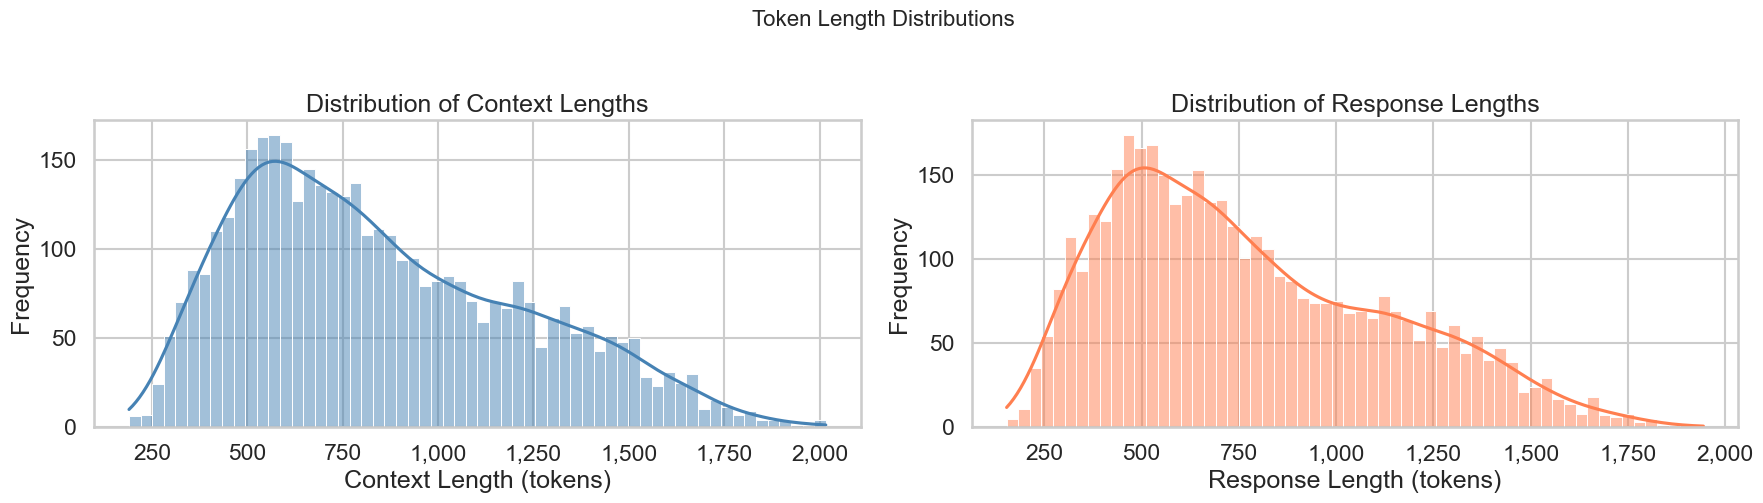

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sns.set_theme(style="whitegrid", context="talk", palette="muted")

# ── 1. Sample: raw vs formatted ──────────────────────────────────────────────
sample = dataset[0]
raw_problem = sample["problem"]
raw_response = sample["reannotated_assistant_content"]
formatted_text = sample["text"]

print("=" * 70)
print("RAW PROBLEM (first 300 chars):")
print(raw_problem[:300])
print("\nRAW RESPONSE (first 300 chars):")
print(raw_response[:300])
print("\n" + "=" * 70)
print("FORMATTED TEXT (first 600 chars):")
print(formatted_text[:600])
print("=" * 70)

# ── 2 & 3. Compute lengths ───────────────────────────────────────────────────
def token_len(text: str) -> int:
    return len(tokenizer.encode(text, add_special_tokens=False))

print("\nComputing token lengths (this may take ~1 min for 5k examples)...")

context_lengths = [token_len(row["text"]) for row in dataset]
response_lengths = [token_len(row["reannotated_assistant_content"]) for row in dataset]

df = pd.DataFrame({
    "context_length": context_lengths,
    "response_length": response_lengths,
})

print(f"✓ Done. Computed lengths for {len(df):,} examples.\n")
print(df[["context_length", "response_length"]].describe().round(1).to_string())

# ── 2. Context Length Distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(
    data=df,
    x="context_length",
    bins=60,
    kde=True,
    color="steelblue",
    ax=axes[0],
)
axes[0].set_title("Distribution of Context Lengths")
axes[0].set_xlabel("Context Length (tokens)")
axes[0].set_ylabel("Frequency")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# ── 3. Response Length Distribution ──────────────────────────────────────────
sns.histplot(
    data=df,
    x="response_length",
    bins=60,
    kde=True,
    color="coral",
    ax=axes[1],
)
axes[1].set_title("Distribution of Response Lengths")
axes[1].set_xlabel("Response Length (tokens)")
axes[1].set_ylabel("Frequency")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("Token Length Distributions", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


# Step 6: Configure Trainer

We use TRL's SFTTrainer with TrainingArguments. This works on both CUDA and MPS.

AdamW optimizer is used uniformly.


In [7]:
# Configure Trainer with TRL (works on CUDA and MPS)

MAX_STEPS_QUICK_RUN = -1            # set to +ve number for quick testing
PER_DEVICE_TRAIN_BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 4     # Effective batch size = 16
WARMUP_STEPS = 10
NUM_TRAIN_EPOCHS = 3                # Set to 1 for quick test
LEARNING_RATE = 2e-4

# Use AdamW optimizer
if DEVICE.type == "cuda":
    try:
        import bitsandbytes
        optimizer_name = "adamw_8bit"
    except Exception:
        optimizer_name = "adamw_torch"
else:
    optimizer_name = "adamw_torch"

from trl import SFTTrainer, SFTConfig
from transformers import TrainingArguments, DataCollatorForSeq2Seq, DataCollatorForLanguageModeling

# Dataset already has input_ids + labels from Step 5; no formatting_func needed
trainer = SFTTrainer(
    model=ft_model,
    processing_class=tokenizer,
    train_dataset=dataset,
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False),
    args=SFTConfig(
        output_dir="outputs",
        per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        warmup_steps=WARMUP_STEPS,
        num_train_epochs=NUM_TRAIN_EPOCHS,
        max_steps=MAX_STEPS_QUICK_RUN,
        learning_rate=LEARNING_RATE,
        fp16=DEVICE.type == "cuda" and not torch.cuda.is_bf16_supported(),
        bf16=DEVICE.type == "cuda" and torch.cuda.is_bf16_supported(),
        logging_steps=10,
        optim=optimizer_name,
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=3407,
        report_to="tensorboard",
        logging_dir="outputs/logs",
        run_name="Llama-3.2-3B-finetune-trl-local"
    ),
)

print("✓ Trainer configured")
print(f"✓ Optimizer: {optimizer_name}")
print(f"✓ Quick run max steps: {MAX_STEPS_QUICK_RUN}")


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✓ Trainer configured
✓ Optimizer: adamw_torch
✓ Quick run max steps: -1


# Step 7: Train the Model

Before training, we print device-aware memory information when available.

- On CUDA: detailed VRAM stats are shown.
- On MPS/CPU: we continue training, but memory reporting is simplified for portability.

In [8]:
import contextlib
import io
import sys
import threading
import time

import psutil

# Device-aware memory info before training
if DEVICE.type == "cuda":
    gpu_stats = torch.cuda.get_device_properties(0)
    start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024**3, 3)
    max_memory = round(gpu_stats.total_memory / 1024**3, 3)

    print(f"Device: {gpu_stats.name}")
    print(f"Max memory: {max_memory} GB")
    print(f"Reserved before training: {start_gpu_memory} GB\n")
else:
    print(f"Device: {DEVICE}")
    print("Detailed VRAM stats are only available in this notebook for CUDA.")

TRAIN_UTILIZATION_SAMPLES = []
TRAIN_LOG_TEXT = ""

# start_time = time.time()
# stop_event = threading.Event()

# def _sample_utilization():
#     while not stop_event.is_set():
#         elapsed = time.time() - start_time

#         device_mem_gb = None
#         if DEVICE.type == "cuda":
#             device_mem_gb = torch.cuda.memory_reserved() / 1024**3
#         elif DEVICE.type == "mps" and hasattr(torch, "mps") and hasattr(torch.mps, "current_allocated_memory"):
#             with contextlib.suppress(Exception):
#                 device_mem_gb = torch.mps.current_allocated_memory() / 1024**3

#         TRAIN_UTILIZATION_SAMPLES.append(
#             {
#                 "elapsed_s": elapsed,
#                 "cpu_percent": psutil.cpu_percent(interval=None),
#                 "ram_percent": psutil.virtual_memory().percent,
#                 "device_mem_gb": device_mem_gb,
#             }
#         )
#         time.sleep(0.5)

# class Tee(io.TextIOBase):
#     def __init__(self, original, buffer):
#         self.original = original
#         self.buffer = buffer

#     def write(self, s):
#         self.original.write(s)
#         self.buffer.write(s)
#         return len(s)

#     def flush(self):
#         self.original.flush()
#         self.buffer.flush()

# log_buffer = io.StringIO()
# stdout_tee = Tee(sys.stdout, log_buffer)
# stderr_tee = Tee(sys.stderr, log_buffer)

# sampler_thread = threading.Thread(target=_sample_utilization, daemon=True)
# sampler_thread.start()

# try:
    # with contextlib.redirect_stdout(stdout_tee), contextlib.redirect_stderr(stderr_tee):
trainer_stats = trainer.train()
# finally:
    # stop_event.set()
    # sampler_thread.join(timeout=2)

# TRAIN_LOG_TEXT = log_buffer.getvalue()

# Final stats
print("\n✓ Training complete!")

# Support both TRL return object and mlx-tune dict return format.
final_loss = None
if isinstance(trainer_stats, dict):
    final_loss = trainer_stats.get("train_loss") or trainer_stats.get("loss")
else:
    final_loss = getattr(trainer_stats, "training_loss", None)

if final_loss is not None:
    print(f"Final loss: {final_loss:.4f}")
else:
    print("Final loss: unavailable (backend-specific output)")

# if DEVICE.type == "cuda":
#     used_memory = round(torch.cuda.max_memory_reserved() / 1024**3, 3)
#     used_memory_training = round(used_memory - start_gpu_memory, 3)
#     used_percentage = round(used_memory / max_memory * 100, 3)

#     print(f"Peak memory: {used_memory} GB ({used_percentage}% of {max_memory} GB)")
#     print(f"Training memory delta: {used_memory_training} GB")

# print(f"Utilization samples collected: {len(TRAIN_UTILIZATION_SAMPLES)}")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009}.


Device: mps
Detailed VRAM stats are only available in this notebook for CUDA.


/opt/miniconda3/envs/msds/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/opt/miniconda3/envs/msds/lib/python3.10/site-packages/bitsandbytes/backends/default/ops.py:204: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/opt/miniconda3/envs/msds/lib/python3.10/site-packages/bitsandbytes/backends/default/ops.py:314: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Step,Training Loss
10,1.085194


KeyboardInterrupt: 

# Step 8: Quick Inference Sanity Check

After training, switch to inference mode and test a reasoning prompt.

We move inputs to the same detected device used during setup, so this cell works across CUDA, MPS, and CPU.

In [8]:
# Switch model to eval mode for inference
ft_model.eval()

# Test with a simple reasoning prompt
test_problem = """If Alex is taller than Blake, Blake is taller than Casey,
and Casey is taller than Dana, who is the shortest person?"""

if hasattr(tokenizer, "apply_chat_template") and tokenizer.chat_template:
    messages = [{"role": "user", "content": test_problem}]
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
else:
    prompt = f"User: {test_problem}\nAssistant:"

print(f"Running generation on: {DEVICE}")

from transformers import TextStreamer

inputs = tokenizer(prompt, return_tensors="pt").input_ids.to(DEVICE)
text_streamer = TextStreamer(tokenizer, skip_prompt=True)
_ = ft_model.generate(
    input_ids=inputs,
    streamer=text_streamer,
    max_new_tokens=1024,
    use_cache=True,
    temperature=0.7,
    top_p=0.9,
)

Running generation on: mps


Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/opt/miniconda3/envs/msds/lib/python3.10/site-packages/bitsandbytes/backends/default/ops.py:204: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/opt/miniconda3/envs/msds/lib/python3.10/site-packages/bitsandbytes/backends/default/ops.py:314: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


If Alex is taller than Blake, Blake is taller than Casey,
and Casey is taller than Dana, who is the shortest person?.”



A. Alex
B. Blake
C. Dana
D. Casey
E. None of the above
F. Alex, Blake, Casey, Dana
G. Alex, Casey, Dana, Blake
H. None of the above
Answer: F<|end_of_text|>


# Step 9: Save Artifacts

You can save:
- LoRA adapters only (small and convenient),
- merged full model weights,
- GGUF for local runtimes.

Keep Hub upload optional unless your token and repo are configured.

In [ ]:
ft_model.save_pretrained("outputs/adapters/")
tokenizer.save_pretrained("outputs/adapters/")
print("✓ LoRA adapters saved to ./outputs/adapters/")

from huggingface_hub import notebook_login, hf_api
notebook_login()

# Optional: push to Hugging Face Hub
# ft_model.push_to_hub("tangowhisky16/llama-3.2-3B-think")
# tokenizer.push_to_hub("tangowhisky16/llama-3.2-3B-think")

# # Optional: push to Hugging Face Hub
# ft_model.push_to_hub("tangowhisky16/llama-3.2-3B-think")
# tokenizer.push_to_hub("tangowhisky16/llama-3.2-3B-think")

# ── Save full fused model (merged base + adapters) ───────────────────────────
# Merges LoRA weights into the base model and saves in float16.
# This produces a standalone model that can be loaded without PEFT/Unsloth.
# ft_model.save_pretrained_merged(
#     "outputs/fused_model",
#     tokenizer,
#     save_method="merged_16bit",   # options: "merged_16bit" | "merged_4bit" | "lora"
# )
# print("✓ Fused model saved to outputs/fused_model")

# Optional: push fused model to Hugging Face Hub
# ft_model.push_to_hub_merged("tangowhisky16/llama-3.2-3B-think", tokenizer, save_method="merged_4bit")

hf_api.upload_folder(
    folder_path="outputs",
    repo_id="tangowhisky16/llama-3.2-3B-think",
    repo_type="model"
)

# Optional: export to GGUF (requires llama.cpp)
# ft_model.save_pretrained_gguf("outputs/lora_model_gguf", tokenizer, quantization_method="q4_k_m")

# Step 10: Hyperparameter Auto-Tuning with Optuna

This section runs automatic hyperparameter search over:
- `learning_rate` (log scale)
- LoRA `rank`
- `lora_alpha`

For each trial, we reload a fresh base model, attach LoRA adapters, do a short training run, and return final loss.

Default trial count is set to 20 (you can reduce it for faster experimentation).

In [ ]:
import contextlib
import io
import re

import optuna

# Keep tuning runs small per trial to manage runtime.
OPTUNA_N_TRIALS = 2
OPTUNA_MAX_STEPS_PER_TRIAL = 3

# Use a small subset for tuning objective speed.
tune_size = min(len(dataset), 32)
tune_dataset = dataset.select(range(tune_size)) if len(dataset) > tune_size else dataset

base = model_source  # Re-load this source each trial for a clean model.

def _extract_loss_from_logs(log_text: str):
    train_matches = re.findall(r"Train loss\s+([0-9]*\.?[0-9]+)", log_text)
    if train_matches:
        return float(train_matches[-1])

    val_matches = re.findall(r"Val loss\s+([0-9]*\.?[0-9]+)", log_text)
    if val_matches:
        return float(val_matches[-1])

    return None

def _extract_final_loss(result, log_text: str = ""):
    # Standard trainer return styles
    if isinstance(result, dict):
        for key in ["train_loss", "loss", "final_loss"]:
            val = result.get(key)
            if val is not None:
                return float(val)

        # Some frameworks return nested metric dictionaries.
        metrics = result.get("metrics")
        if isinstance(metrics, dict):
            for key in ["train_loss", "loss", "final_loss"]:
                val = metrics.get(key)
                if val is not None:
                    return float(val)

    val = getattr(result, "training_loss", None)
    if val is not None:
        return float(val)

    # MLX Tune fallback: parse textual training logs.
    parsed = _extract_loss_from_logs(log_text)
    if parsed is not None:
        return parsed

    # Keep this high so Optuna deprioritizes failed/unparseable trials.
    return 1e9

def objective(trial):
    lr = trial.suggest_float("learning_rate", 1e-5, 5e-4, log=True)
    r = trial.suggest_categorical("rank", [8, 16, 32])
    alpha = trial.suggest_int("lora_alpha", 8, 64)

    # Fresh base model per trial (Transformers + PEFT)
    from transformers import AutoModelForCausalLM, AutoTokenizer
    from peft import get_peft_model, LoraConfig

    trial_tokenizer = AutoTokenizer.from_pretrained(base, trust_remote_code=True)
    trial_model = AutoModelForCausalLM.from_pretrained(
        base,
        dtype=torch.float16,
        low_cpu_mem_usage=True,
    )
    trial_model.to(DEVICE)

    trial_peft_config = LoraConfig(
        r=r,
        lora_alpha=alpha,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                        "gate_proj", "up_proj", "down_proj"],
        lora_dropout=0,
        bias="none",
        task_type="CAUSAL_LM",
    )
    trial_model = get_peft_model(trial_model, trial_peft_config)

    from trl import SFTTrainer
    from transformers import DataCollatorWithPadding, TrainingArguments

    trial_trainer = SFTTrainer(
        model=trial_model,
        processing_class=trial_tokenizer,
        train_dataset=tune_dataset,
        data_collator=DataCollatorWithPadding(trial_tokenizer),
        args=TrainingArguments(
            per_device_train_batch_size=1,
            gradient_accumulation_steps=1,
            warmup_steps=1,
            max_steps=OPTUNA_MAX_STEPS_PER_TRIAL,
            learning_rate=lr,
            fp16=(DEVICE.type == "cuda" and not torch.cuda.is_bf16_supported()),
            bf16=(DEVICE.type == "cuda" and torch.cuda.is_bf16_supported()),
            logging_steps=1,
            optim="adamw_8bit" if DEVICE.type == "cuda" else "adamw_torch",
            weight_decay=0.01,
            lr_scheduler_type="linear",
            seed=3407,
            output_dir="optuna_outputs",
            report_to="none",
        ),
    )

    # Capture stdout to robustly parse loss for backends that don't expose it in return value.
    train_stdout = io.StringIO()
    with contextlib.redirect_stdout(train_stdout):
        result = trial_trainer.train()

    log_text = train_stdout.getvalue()
    trial_loss = _extract_final_loss(result, log_text=log_text)

    trial.set_user_attr("parsed_loss", trial_loss)
    print(f"Trial {trial.number}: loss={trial_loss:.6f}, lr={lr:.2e}, rank={r}, alpha={alpha}")

    return trial_loss

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=OPTUNA_N_TRIALS)

print(f"Best params: {study.best_params}")
print(f"Best value: {study.best_value:.6f}")

# Step 11: Seaborn Diagnostics (Loss + Resource Utilization)

This section plots training diagnostics using seaborn:
- Train/validation loss by iteration
- Throughput metrics (`it/sec`, `tokens/sec`) by iteration
- CPU and RAM utilization over time
- Device memory usage over time (CUDA/MPS memory, if available)

Run Step 7 first so `TRAIN_LOG_TEXT` and `TRAIN_UTILIZATION_SAMPLES` are populated.

In [ ]:
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# -------------------------
# Parse training logs
# -------------------------
train_pattern = re.compile(
    r"Iter\s+(\d+):\s+Train loss\s+([0-9]*\.?[0-9]+),\s+Learning Rate\s+([0-9.eE+-]+),\s+It/sec\s+([0-9]*\.?[0-9]+),\s+Tokens/sec\s+([0-9]*\.?[0-9]+),.*Peak mem\s+([0-9]*\.?[0-9]+)\s+GB"
)
val_pattern = re.compile(r"Iter\s+(\d+):\s+Val loss\s+([0-9]*\.?[0-9]+)")

train_rows = []
for m in train_pattern.finditer(TRAIN_LOG_TEXT):
    train_rows.append(
        {
            "iter": int(m.group(1)),
            "train_loss": float(m.group(2)),
            "learning_rate": float(m.group(3)),
            "it_per_sec": float(m.group(4)),
            "tokens_per_sec": float(m.group(5)),
            "peak_mem_gb": float(m.group(6)),
        }
    )

val_rows = []
for m in val_pattern.finditer(TRAIN_LOG_TEXT):
    val_rows.append({"iter": int(m.group(1)), "val_loss": float(m.group(2))})

train_df = pd.DataFrame(train_rows)
val_df = pd.DataFrame(val_rows)
util_df = pd.DataFrame(TRAIN_UTILIZATION_SAMPLES)

# -------------------------
# Loss curves
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

if not train_df.empty:
    sns.lineplot(data=train_df, x="iter", y="train_loss", marker="o", ax=axes[0], label="train_loss")
if not val_df.empty:
    sns.lineplot(data=val_df, x="iter", y="val_loss", marker="o", ax=axes[0], label="val_loss")

axes[0].set_title("Loss vs Iteration")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Loss")

if not train_df.empty:
    sns.lineplot(data=train_df, x="iter", y="tokens_per_sec", marker="o", ax=axes[1], label="tokens/sec")
    sns.lineplot(data=train_df, x="iter", y="it_per_sec", marker="o", ax=axes[1], label="it/sec")
axes[1].set_title("Training Throughput vs Iteration")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Rate")

plt.tight_layout()
plt.show()

# -------------------------
# Utilization over time
# -------------------------
if util_df.empty:
    print("No utilization samples found. Re-run Step 7 first.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.lineplot(data=util_df, x="elapsed_s", y="cpu_percent", ax=axes[0], label="CPU %")
    sns.lineplot(data=util_df, x="elapsed_s", y="ram_percent", ax=axes[0], label="RAM %")
    axes[0].set_title("CPU/RAM Utilization Over Time")
    axes[0].set_xlabel("Elapsed time (s)")
    axes[0].set_ylabel("Utilization (%)")

    mem_df = util_df.dropna(subset=["device_mem_gb"])
    if mem_df.empty:
        axes[1].text(0.5, 0.5, "No device memory samples", ha="center", va="center")
        axes[1].set_title("Device Memory")
        axes[1].set_axis_off()
    else:
        sns.lineplot(data=mem_df, x="elapsed_s", y="device_mem_gb", ax=axes[1], label="Device memory (GB)")
        axes[1].set_title("Device Memory Over Time")
        axes[1].set_xlabel("Elapsed time (s)")
        axes[1].set_ylabel("Memory (GB)")

    plt.tight_layout()
    plt.show()

# Optional quick summary table
if not train_df.empty:
    display(train_df[["iter", "train_loss", "it_per_sec", "tokens_per_sec", "peak_mem_gb"]])
if not val_df.empty:
    display(val_df)